# Assignment 2
### Understanding Uncertainty
### Due 9/12

1. 'State Bottle Retail' is the price at which the bottle is sold, while 'State Bottle Cost' is the price the state pays for a bottle.
- How do you define the most profitable item? Why? Explain your thinking.
- Use `.groupby` calculations to determine the most profitable liquors sold in Iowa.
- Make a plot of the top liquors.

In [1]:
import pandas as pd

In [2]:
iowa = pd.read_csv('data/iowa.csv')
iowa.head()

,Invoice/Item Number,Date,Store Number,Store Name,Zip Code,Category Name,Vendor Name,Item Number,Item Description,Bottle Volume (ml),State Bottle Cost,State Bottle Retail,Bottles Sold,Sale (Dollars)
0,INV-59108400026,06/06/2023,3723,J D SPIRITS LIQUOR,51040,STRAIGHT RYE WHISKIES,INFINIUM SPIRITS,27102,TEMPLETON RYE 4YR,750,18.09,27.14,2,54.28
1,S16879800057,01/16/2014,3926,LIQUOR DOWNTOWN / IOWA CITY,52240,VODKA 80 PROOF,HEAVEN HILL BRANDS,35416,BURNETT'S VODKA 80 PRF,750,4.84,7.26,12,87.12
2,INV-05301100019,06/05/2017,3829,GARY'S FOODS / MT VERNON,52314,CANADIAN WHISKIES,DIAGEO AMERICAS,11296,CROWN ROYAL,750,15.59,23.39,6,135.66
3,INV-40973500083,10/14/2021,5102,WILKIE LIQUORS,52314,AMERICAN SCHNAPPS,JIM BEAM BRANDS,82787,DEKUYPER BUTTERSHOTS,1000,7.87,11.81,12,141.72
4,INV-17022500013,01/18/2019,2560,HY-VEE FOOD STORE / MARION,52302,WHISKEY LIQUEUR,SAZERAC COMPANY INC,64863,FIREBALL CINNAMON WHISKEY,200,2.50,3.75,12,45.00


I would define the most profitable item to be the item that has the largest "total profit" as described by
'Total Profit' = (State Bottle Cost - Stat Bottle Retail)(Bottles Sold)
My thinking is that I want the bottle with the best profit margin, but also factoring in how many bottles it sells. This forumla should give us the most profitbale item.

In [ ]:
iowa["Profit Per Bottle"] = iowa["State Bottle Retail"] - iowa["State Bottle Cost"]
iowa["Total Profit"] = iowa["Profit Per Bottle"] * iowa["Bottles Sold"]

profit_per_item = iowa.groupby("Item Description")["Total Profit"].sum().sort_values(ascending=False)

print(profit_per_item.head(5))

Item Description
TITOS HANDMADE VODKA         364074.35
BLACK VELVET                 274676.85
FIREBALL CINNAMON WHISKEY    187535.22
CROWN ROYAL                  160981.95
CROWN ROYAL REGAL APPLE      122880.40
Name: Total Profit, dtype: float64


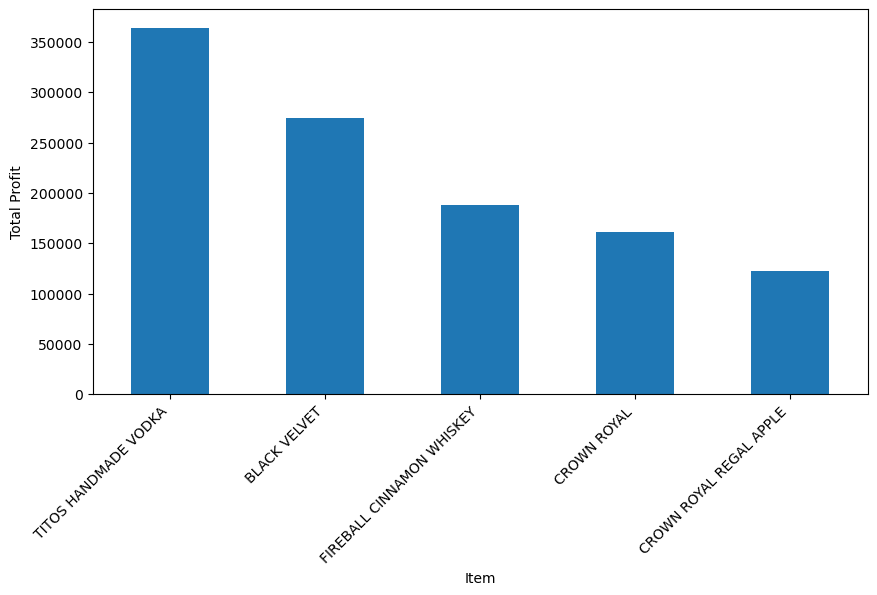

In [6]:
import matplotlib.pyplot as plt

top5 = profit_per_item.head(5)

plt.figure(figsize=(10,5))
top5.plot(kind='bar')
plt.ylabel('Total Profit')
plt.xlabel('Item')
plt.xticks(rotation=45, ha="right")
plt.show()

2. This question is to further explore broadcasting in NumPy.

- In the first code chunk below, there are two vectors, $x$ and $y$. What happens when you try to subtract them?
- Instead, try `x.reshape(-1,1)-y.reshape(1,-1)`. What do you get?
- Try `x.reshape(1,-1)-y.reshape(-1,1)`. Compare the results to your previous answer.
- Write two double for-loops to replicate the results of the previous two answers. 
- Clearly explain how `x.reshape(1,-1)` and `x.reshape(-1,1)` change $x$

In [7]:
import numpy as np

x = np.array([1,3,5])
y = np.array([2,5])

In [8]:
x - y

ValueError: operands could not be broadcast together with shapes (3,) (2,) 

We get an error because the two arrays are different shapes.

In [10]:
x.reshape(-1,1) - y.reshape(1,-1)

array([[-1, -4],
       [ 1, -2],
       [ 3,  0]])

Since we reshaped, numpy was able to then broadcast x and y so that subtraction was possible, going into a full (3,2) matrix

In [11]:
x.reshape(1,-1)-y.reshape(-1,1)

array([[-1,  1,  3],
       [-4, -2,  0]])

This allows the same broadcatsing to occur but we transposed both matricies so this this the transpose of the prior subtraction matrix.

In [14]:
matrix1 = np.zeros((len(x),len(y)),dtype=int)

for i in range(len(x)):
    for j in range(len(y)):
        matrix1[i,j] = x[i] - y[j]

print(matrix1)

[[-1 -4]
 [ 1 -2]
 [ 3  0]]


In [15]:
matrix2 = np.zeros((len(y),len(x)),dtype=int)

for i in range(len(y)):
    for j in range(len(x)):
        matrix2[i,j] = x[j] - y[i]

print(matrix2)

[[-1  1  3]
 [-4 -2  0]]


x is a one dimensional array, its shape is (3,) with a single axis. When we use x.reshape(1, -1), the 1 is saying to keep the row in tact, and the -1 tells numpy to automatically figure out the number of columns based on the legth of the array. It sees a length of 3, and therefore makes the shape of the resulting 2D array (1,3), which is why it shows as [[1 3 5]].

x.reshape(-1, 1) does something similar, except when we pass 1 in the column place in (-1, 1), it is telling numpy to set the number of columns to 1. Then the -1 is doing something similar to the other case where it is just figuring out the length and setting the rows to 3, so we get the transposed 2D array of shape (3,1) and it shows as [[1
              3
              5]]

We must do this in order to make the arrays 2 dimensional and able to have broadcasting operations done.

3. The indicator function $\mathbb{I}\{ x \le z \}$ takes the value 0 if $x>z$ and 1 if $x \le z$ is true, or
$$
\mathbb{I}\{x \le z\} = \begin{cases}
0, &x > z \\
1, &x \le z
\end{cases}
$$

- For $x = 3$, plot the indicator function for any $z$
- Explain how $ 1- \mathbb{I}\{ x \le z \} = \mathbb{I}\{ x > z \}$. Drawing a plot might help, or looking at the definition given above.
- The code below generates a random sample for different numbers of observations, $N = 3, 30, 300, 3000 $. Write a function to compute the ECDF curve for each sample, and plot your results.
- Describe in your own words what happens to the ECDF qualitatively as the sample size $N$ increases

Text(0.5, 1.0, 'Indicator function')

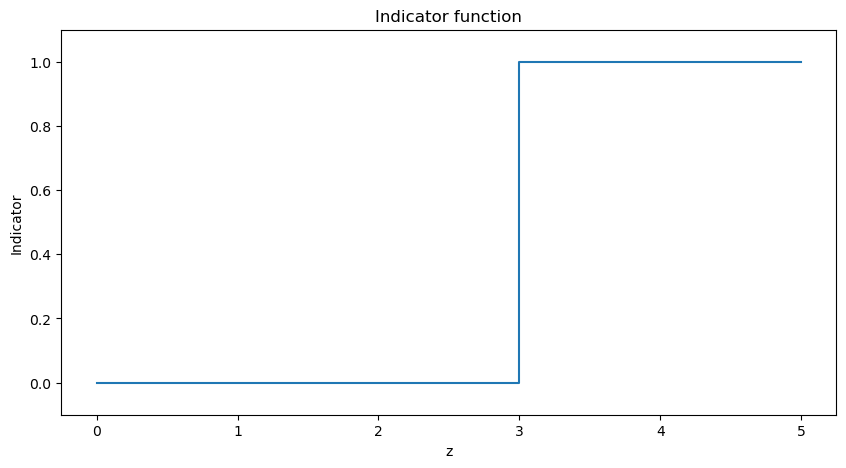

In [19]:
x = 3
z = np.array([0,1,2,3,4,5])

indicator_function = (x <= z).astype(int)

plt.figure(figsize=(10,5))
plt.step(z, indicator_function, where='post')
plt.ylim(-0.1,1.1)
plt.xlabel('z')
plt.ylabel('Indicator')
plt.title('Indicator function')

In [4]:
import numpy as np
import seaborn as sns

rng = np.random.default_rng(100)

for N in (3,30,300,3000):
    X = rng.normal(0,1,N)
    # ECDF plot goes here:


4. A **quantile** generalizes the concept of the median so that instead of 50% of the mass below and 50% above, the $q$-quantile is the value for which $q$ proportion of the data are below that value and $(1-q)$ proportion of the data are above that value. This is a concept of **order**.

- Write a function that computes any quantile without using Numpy's `np.quantile`
- Write a function that computes the **Interquartile Range (IQR)** -- the .25 quantile and the .75 quantile, which brackets 50% of the data -- and the **whiskers**: $\pm 1.5 \times \text{IQR}$ from the edges of the IQR
- Write a function that computes a five-number summary and values for a boxplot: the minimum, the .25 quantile, the median, the .75 quantile, and the maximum, and the whiskers
- Anything outside the whiskers is an **outlier**; write a function that returns a Boolean vector indicating if the observations are outliers.
- For a numeric variable of your choice from one of the datasets, apply your functions from above, and compare your answers with `sns.boxplot` and `df.describe`. 

5. The kernel density estimator captures the concentration of the data around various points, and is defined as
$$
\hat{f}_{N,h}(z) = \frac{1}{N} \sum_{i=1}^N \frac{1}{h} k \left( \frac{x_i - z}{h}\right)
$$
where $h$ is the bandwidth and $k()$ is one of the kernel functions from the class materials (Gaussian, Epanechnikov, uniform, triangular).

- Write a function that takes the bandwidth $h$ as given, and computes and plots $\hat{f}_{N,h}(z)$, for the kernels listed in the slides
- Write a function that computes the plug-in bandwidth
- Use your functions to analyze some numeric variables from a dataset of your choice, using a variety of bandwidths
- Compare bandwidths that are greater or less than the plug-in value with the results for the plug-in value. When does the KDE appear to be overfitting? Underfitting?